In [1]:
import os, sys
import pickle

import matplotlib_inline
sys.path.append("../")

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
from matplotlib import gridspec
from matplotlib import ticker
from matplotlib.lines import Line2D

from tqdm import tqdm

from scipy.interpolate import interp1d
import numpy as np
import pymaster as nmt

matplotlib_inline.backend_inline.set_matplotlib_formats('retina')

%matplotlib inline
%load_ext autoreload
%autoreload 2
# Load plot settings
import healpy as hp
from plot_params import params
pylab.rcParams.update(params)

cols_default = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [9]:
# load power spectra
binning = nmt.NmtBin.from_nside_linear(2048, 10)

mccarthy_Cls = np.load("data/real_Planck_auto_Cls_binning10.npy")
mock_planck_Cls = np.load("data/mock_Planck_auto_Cls_binning10.npy")
small_beam = np.load("data/Planck_small_beam_auto_Cls_binning10.npy")
fiducial_SKA = np.load("data/fiducial_SKA_auto_Cls_binning10.npy")
SKA_100mJy = np.load("data/SKA_100mJy_auto_Cls_binning10.npy")

signal = np.load("data/Cl_PP_mA5.623e-13.npy")
signal_ls = np.load("data/ls.npy")

In [11]:
mccarthy_covs = np.load("data/real_Planck_covariance_clean_PP_binning10_K22.npy")
mock_planck_covs = np.load("data/mock_Planck_covariance_clean_PP_binning10_K22.npy")
small_beam_covs = np.load("data/Planck_small_beam_covariance_clean_PP_binning10_K22.npy")
fiducial_SKA_covs = np.load("data/fiducial_SKA_covariance_clean_PP_binning10_K22.npy")
SKA_100mJy_covs = np.load("data/SKA_100mJy_covariance_clean_PP_binning10_K22.npy")

In [12]:
#this is the normalization factor used in McCarthy et al.
TCMB_eV = 0.000235264 
x = 2 * np.pi * 0.000232349 /TCMB_eV #353 * 2pi
mc_prefac = TCMB_eV * x**2 / (1- np.exp(-x))
epsilon = 3e-7
# epsilon_us  

In [13]:
new_prefac = 2* np.pi * 410e6 * 6.58212e-16 # convert MHz to eV
# changes normalization to be at radio frequency

In [14]:
# load power spectra
cross_binning = nmt.NmtBin.from_nside_linear(2048, 150)

SKA_cross = np.load("data/fiducial_SKA_cross_Pg_Cls_binning150_K22.npy")
SKA_cross_covs = np.load('data/fiducial_SKA_covariance_clean_gP_binning150_K22.npy')

cross_signal = np.load("data/Cl_gP_mA5.623e-13_modelK22.npy")

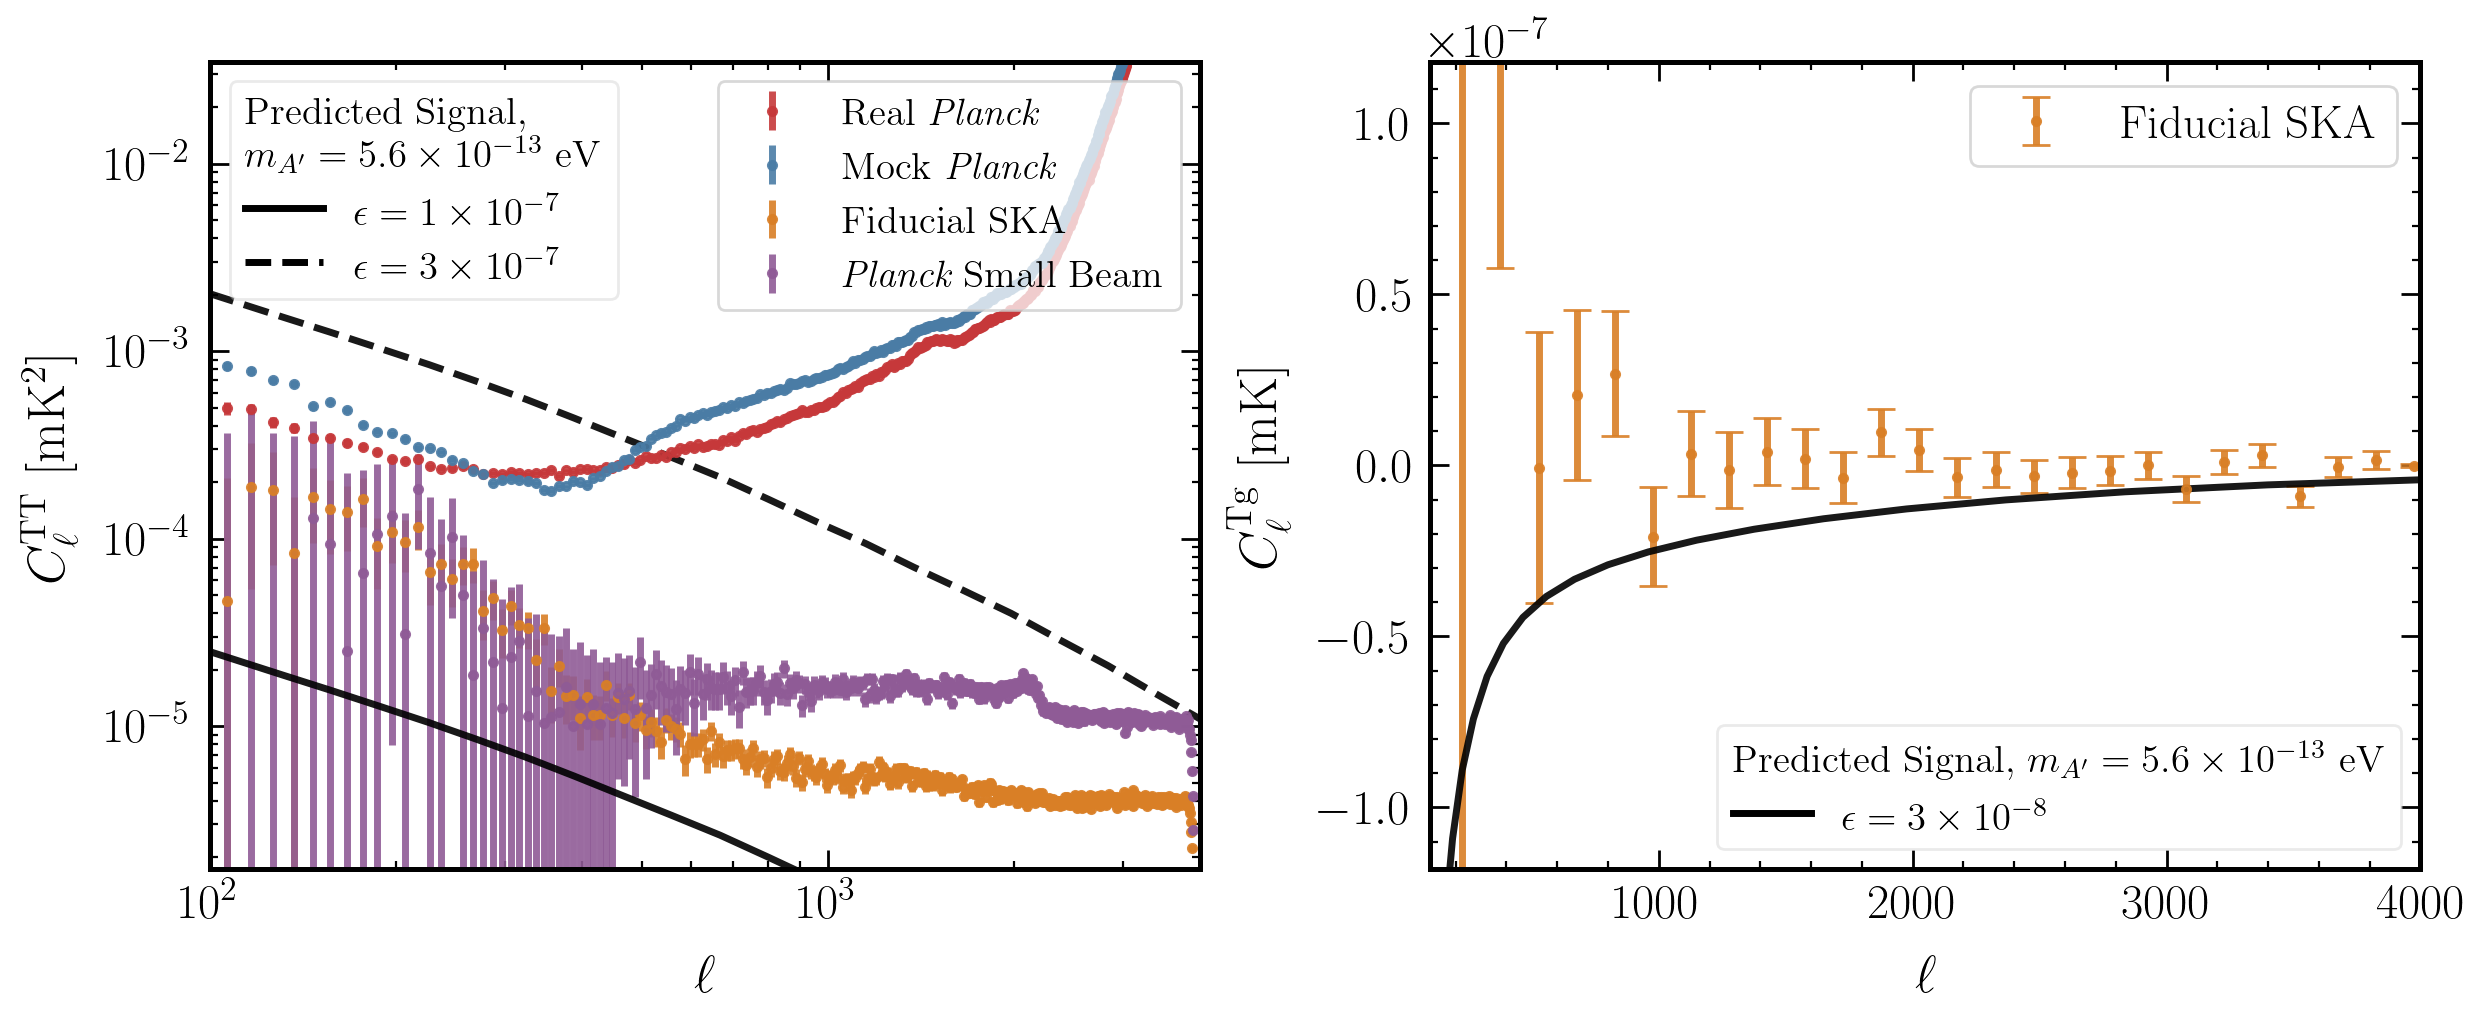

In [16]:
from matplotlib.lines import lineStyles

fig, ax = plt.subplots(1, 2, figsize=(2*6.153846153846153, 5.0), constrained_layout=True)


ax[0].errorbar(
    binning.get_effective_ells(),
    mccarthy_Cls * mc_prefac**2 / new_prefac**2 ,
    yerr=mc_prefac**2 * np.sqrt(np.diag(mccarthy_covs)) / new_prefac**2,
    capsize=0,
    linestyle=" ",
    marker=".",
    label=r"Real \textit{Planck}",
    color=cols_default[0],
)

ax[0].errorbar(
    binning.get_effective_ells(),
    mock_planck_Cls * mc_prefac**2 / new_prefac**2,
    yerr= mc_prefac**2 * np.sqrt(np.diag(mock_planck_covs)) / new_prefac**2,
    capsize=0,
    linestyle=" ",
    marker=".",
    label=r"Mock \textit{Planck}",
    color=cols_default[1],
)

ax[0].errorbar(
    binning.get_effective_ells(),
    fiducial_SKA / new_prefac**2,
    yerr=np.sqrt(np.diag(fiducial_SKA_covs)) / new_prefac**2,
    capsize=0,
    linestyle=" ",
    marker=".",
    label="Fiducial SKA",
    color=cols_default[4],
)

ax[0].errorbar(
    binning.get_effective_ells(),
    small_beam / new_prefac**2,
    yerr=np.sqrt(np.diag(small_beam_covs)) / new_prefac**2,
    capsize=0,
    linestyle=" ",
    marker=".",
    label=r"$\textit{Planck}$ Small Beam",
    color=cols_default[3],
)
ax[0].plot(
    signal_ls,
    (2.73e3) ** 2 * (1e-7)**4 * signal / new_prefac**2,
    linestyle="-",
    color="k",
    # label="Theoretical Signal",
)
ax[0].plot(
    signal_ls,
    (2.73e3) ** 2 * (3e-7)**4 * signal / new_prefac**2,
    linestyle="--",
    color="k",
    # label="Theoretical Signal",
)
ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[0].set_xlim(100, 4000)
ax[0].set_ylim(0.5e-17 / new_prefac**2, 1e-13 / new_prefac**2)

small_eps_line = Line2D([0,1],[0,1],linestyle='-', color='k')
big_eps_line = Line2D([0,1],[0,1],linestyle='--', color='k')
legend2 = ax[0].legend([small_eps_line, big_eps_line], [r"$\epsilon=1\times10^{-7}$", r"$\epsilon=3\times10^{-7}$"], 
                     fontsize=14, loc="upper left", frameon=True, 
                     title="Predicted Signal,\n" + r"$m_{A'}=5.6\times 10^{-13}$ eV",
                     title_fontsize=14)

# legend2.set_title("Predicted Signal,\n" + r"$m_{A'}=5.6\times 10^{-13}$ eV")
ax[0].add_artist(legend2)
legend2._legend_box.align = 'left'
    
legend1 = ax[0].legend(fontsize=14, frameon=True, loc="upper right", framealpha=0.75) # loc='center left', bbox_to_anchor=(1, 0.5))

ax[0].set_xlabel(r"$\ell$")
ax[0].set_ylabel(r"$C^{\rm TT}_\ell$ [mK$^2$]")


ax[1].errorbar(
    cross_binning.get_effective_ells(),
    SKA_cross / new_prefac,
    yerr=np.sqrt(np.diag(SKA_cross_covs)) / new_prefac,
    # capsize=0,
    linestyle=" ",
    marker=".",
    label="Fiducial SKA",
    color=cols_default[4],
)

ax[1].plot(
    signal_ls,
    -(2.73e3) * (3e-8)**2 * cross_signal /new_prefac,
    linestyle="-",
    color="k",
    # label="Theoretical Signal",
)

legend2 = ax[1].legend([small_eps_line], [r"$\epsilon=3\times 10^{-8}$"], 
                     loc="lower right", frameon=True, 
                     title=r"Predicted Signal, $m_{A'}=5.6\times 10^{-13}$ eV", 
                     title_fontsize=14, fontsize=14)

ax[1].add_artist(legend2)
legend2._legend_box.align = 'left'

legend1 = ax[1].legend(frameon=True, loc="upper right", framealpha=0.75) # loc='center left', bbox_to_anchor=(1, 0.5))

# ax[1].set_xscale("log")
ax[1].set_xlim(100, 4000)
ax[1].set_ylim(-0.2e-12/new_prefac,  0.2e-12/new_prefac)

ax[1].set_xlabel(r"$\ell$")
ax[1].set_ylabel(r"$C^{\rm Tg}_\ell$ [mK]")
ax[1].ticklabel_format(axis='y', style='sci', scilimits=(-4, 4))
# plt.savefig("plots/Cl_comparsion.pdf", bbox_inches="tight")

# plt.xlabel(r"$\ell$")
# plt.ylabel(r"$C^{\rm TT}_\ell$ [mK$^2$]")
# plt.savefig("plots/mccarthy_comparison.pdf", bbox_inches="tight")

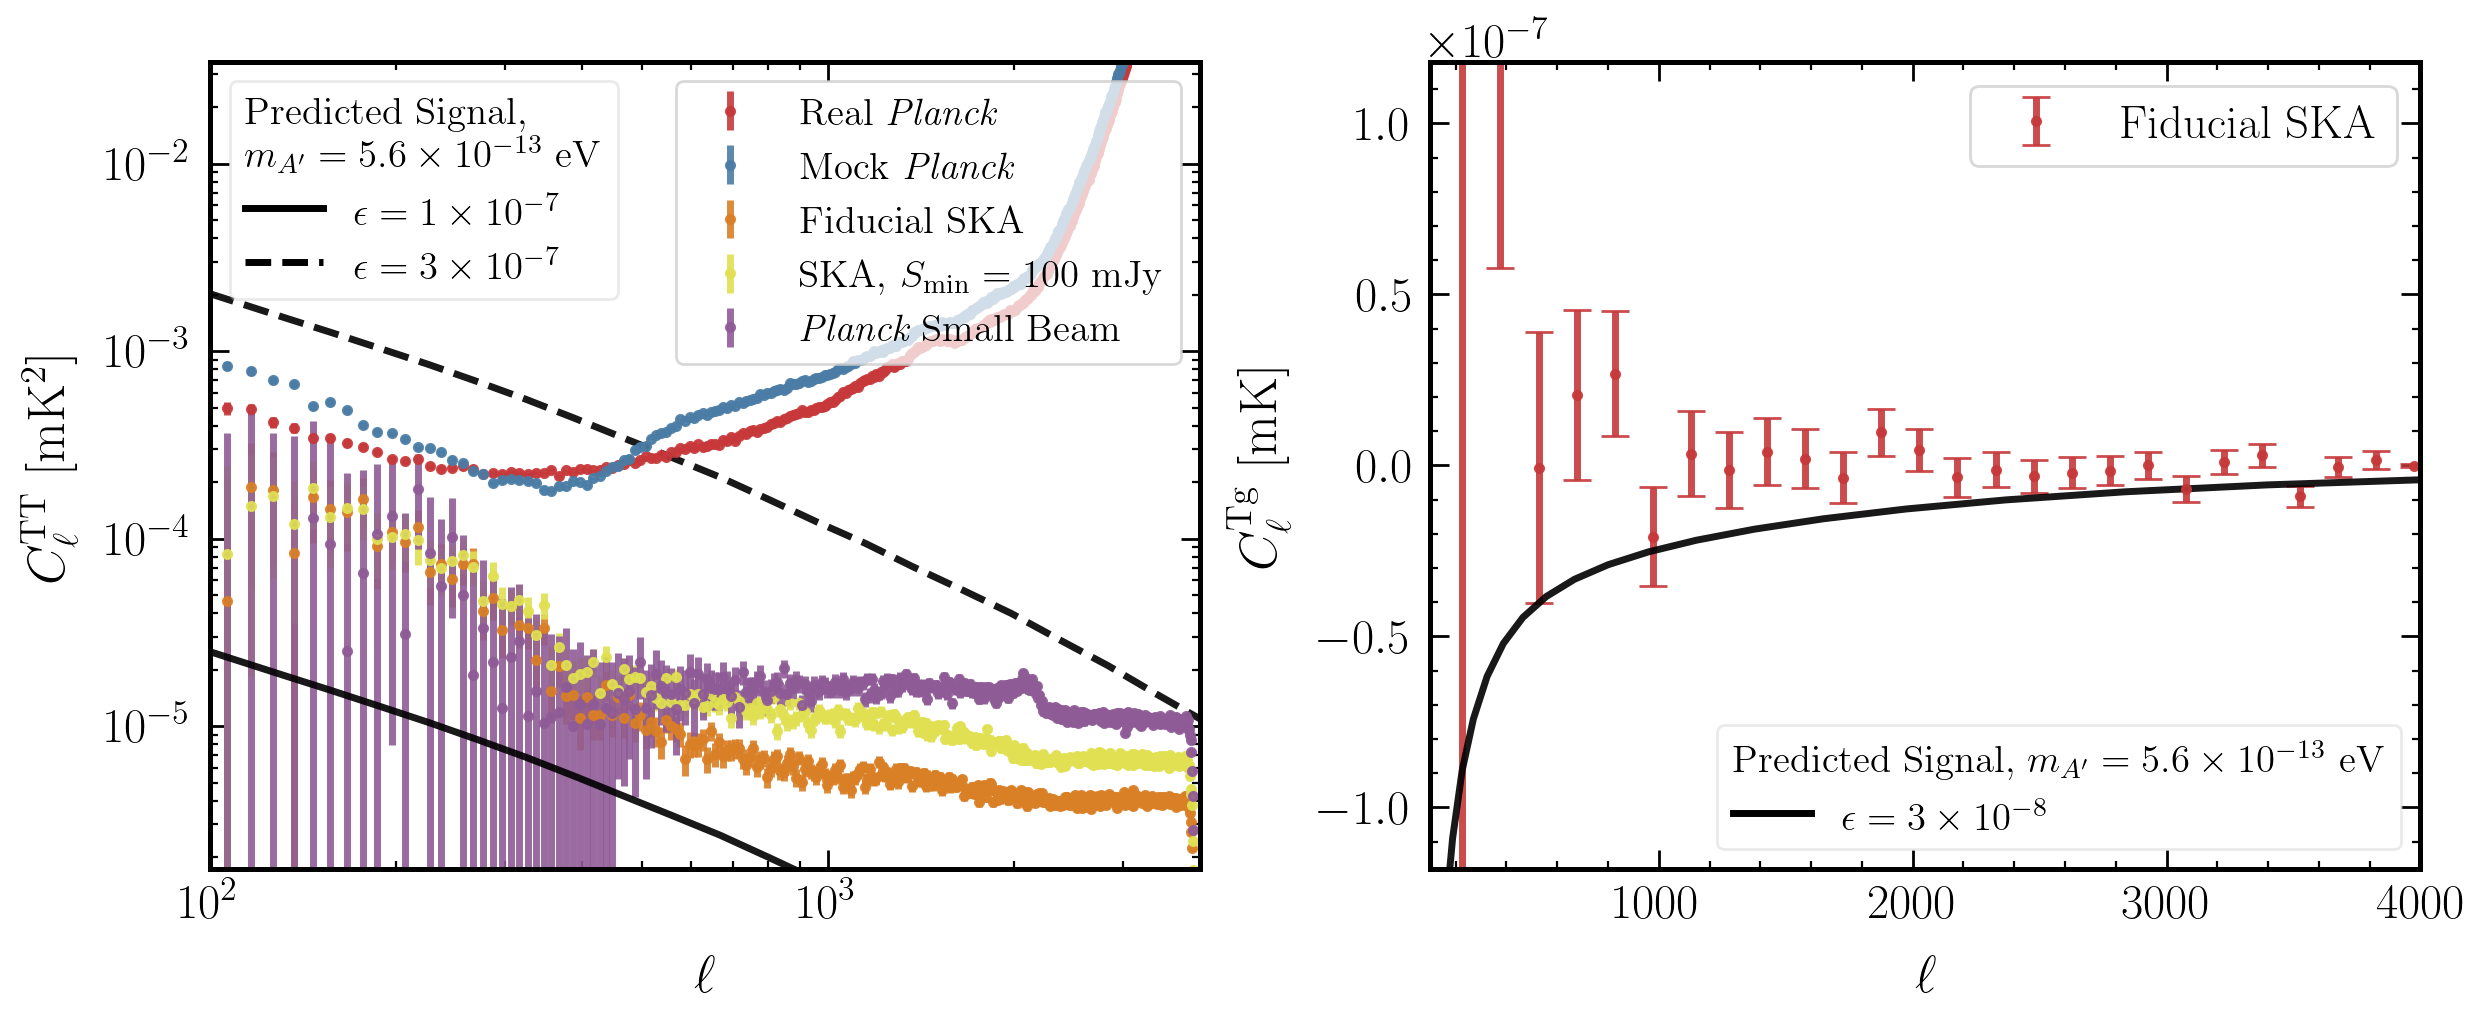

In [ ]:
from matplotlib.lines import lineStyles

fig, ax = plt.subplots(1, 2, figsize=(2*6.153846153846153, 5.0), constrained_layout=True)


ax[0].errorbar(
    binning.get_effective_ells(),
    mccarthy_Cls * mc_prefac**2 / new_prefac**2 ,
    yerr=mc_prefac**2 * np.sqrt(np.diag(mccarthy_covs)) / new_prefac**2,
    capsize=0,
    linestyle=" ",
    marker=".",
    label=r"Real \textit{Planck}",
    color=cols_default[0],
)
ax[0].errorbar(
    binning.get_effective_ells(),
    mock_planck_Cls * mc_prefac**2 / new_prefac**2,
    yerr= mc_prefac**2 * np.sqrt(np.diag(mock_planck_covs)) / new_prefac**2,
    capsize=0,
    linestyle=" ",
    marker=".",
    label=r"Mock \textit{Planck}",
    color=cols_default[1],
)
ax[0].errorbar(
    binning.get_effective_ells(),
    fiducial_SKA / new_prefac**2,
    yerr=np.sqrt(np.diag(fiducial_SKA_covs)) / new_prefac**2,
    capsize=0,
    linestyle=" ",
    marker=".",
    label="Fiducial SKA",
    color=cols_default[4],
)
ax[0].errorbar(
    binning.get_effective_ells(),
    SKA_100mJy / new_prefac**2,
    yerr=np.sqrt(np.diag(SKA_100mJy_covs)) / new_prefac**2,
    capsize=0,
    linestyle=" ",
    marker=".",
    label=r"SKA, $S_{\rm min}=100$ mJy",
    color=cols_default[5],
)
ax[0].errorbar(
    binning.get_effective_ells(),
    small_beam / new_prefac**2,
    yerr=np.sqrt(np.diag(small_beam_covs)) / new_prefac**2,
    capsize=0,
    linestyle=" ",
    marker=".",
    label=r"$\textit{Planck}$ Small Beam",
    color=cols_default[3],
)
ax[0].plot(
    signal_ls,
    (2.73e3) ** 2 * (1e-7)**4 * signal / new_prefac**2,
    linestyle="-",
    color="k",
    # label="Theoretical Signal",
)
ax[0].plot(
    signal_ls,
    (2.73e3) ** 2 * (3e-7)**4 * signal / new_prefac**2,
    linestyle="--",
    color="k",
    # label="Theoretical Signal",
)
ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[0].set_xlim(100, 4000)
ax[0].set_ylim(0.5e-17 / new_prefac**2, 1e-13 / new_prefac**2)

small_eps_line = Line2D([0,1],[0,1],linestyle='-', color='k')
big_eps_line = Line2D([0,1],[0,1],linestyle='--', color='k')
legend2 = ax[0].legend([small_eps_line, big_eps_line], [r"$\epsilon=1\times10^{-7}$", r"$\epsilon=3\times10^{-7}$"], 
                     fontsize=14, loc="upper left", frameon=True, 
                     title="Predicted Signal,\n" + r"$m_{A'}=5.6\times 10^{-13}$ eV",
                     title_fontsize=14)

# legend2.set_title("Predicted Signal,\n" + r"$m_{A'}=5.6\times 10^{-13}$ eV")
ax[0].add_artist(legend2)
legend2._legend_box.align = 'left'
    
legend1 = ax[0].legend(fontsize=14, frameon=True, loc="upper right", framealpha=0.75) # loc='center left', bbox_to_anchor=(1, 0.5))

ax[0].set_xlabel(r"$\ell$")
ax[0].set_ylabel(r"$C^{\rm TT}_\ell$ [mK$^2$]")


ax[1].errorbar(
    cross_binning.get_effective_ells(),
    SKA_cross / new_prefac,
    yerr=np.sqrt(np.diag(SKA_cross_covs)) / new_prefac,
    # capsize=0,
    linestyle=" ",
    marker=".",
    label="Fiducial SKA",
    color=cols_default[0],
)

ax[1].plot(
    signal_ls,
    -(2.73e3) * (3e-8)**2 * cross_signal /new_prefac,
    linestyle="-",
    color="k",
    # label="Theoretical Signal",
)

legend2 = ax[1].legend([small_eps_line], [r"$\epsilon=3\times 10^{-8}$"], 
                     loc="lower right", frameon=True, 
                     title=r"Predicted Signal, $m_{A'}=5.6\times 10^{-13}$ eV", 
                     title_fontsize=14, fontsize=14)

ax[1].add_artist(legend2)
legend2._legend_box.align = 'left'

legend1 = ax[1].legend(frameon=True, loc="upper right", framealpha=0.75) # loc='center left', bbox_to_anchor=(1, 0.5))

# ax[1].set_xscale("log")
ax[1].set_xlim(100, 4000)
ax[1].set_ylim(-0.2e-12/new_prefac,  0.2e-12/new_prefac)

ax[1].set_xlabel(r"$\ell$")
ax[1].set_ylabel(r"$C^{\rm Tg}_\ell$ [mK]")
ax[1].ticklabel_format(axis='y', style='sci', scilimits=(-4, 4))
# plt.savefig("plots/prd_Cl_comparsion.pdf", bbox_inches="tight")
